# 🔍 Token Length Analysis & MAX_LEN Optimization

이 노트북은 `klue/roberta-base` 토크나이저를 사용하여 데이터셋의 실제 토큰 길이 분포를 분석합니다.
이를 통해 모델 학습 시 GPU 메모리와 학습 효율 사이의 최적점인 `MAX_LEN`을 결정합니다.

## 🎯 분석 목표
1. **토큰 길이 분포 확인**: 전체 데이터의 토큰 길이 통계(평균, 중앙값, 최대값) 파악
2. **클래스별 비교**: Human vs AI 간의 글 길이 차이 분석
3. **Truncation 영향도 분석**: 특정 `MAX_LEN` 설정 시 데이터가 얼마나 잘리는지 계산
4. **결정**: 베이스라인 모델에 적용할 최적의 `MAX_LEN` 도출

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer
from tqdm.auto import tqdm

import matplotlib.font_manager as fm

# Mac 한글 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

sns.set_theme(style="whitegrid", palette="muted")

## 📂 데이터 로드 (Sampling)
데이터가 크므로 전체의 일부(예: 20,000개)만 샘플링하여 분석을 진행합니다.

In [2]:
DATA_PATH = '/Users/youngjinson/Downloads/open/train.csv'
TOKENIZER_NAME = 'klue/roberta-base'

# 데이터 로드
df = pd.read_csv(DATA_PATH)

# 분석을 위한 샘플링 (시간 절약)
sample_df = df.sample(n=min(20000, len(df)), random_state=42).reset_index(drop=True)

print(f"전체 데이터 개수: {len(df):,}")
print(f"분석용 샘플 개수: {len(sample_df):,}")

전체 데이터 개수: 97,172
분석용 샘플 개수: 20,000


## 🧩 토큰 길이 계산
각 텍스트를 실제로 토크나이징하여 토큰 개수를 추출합니다.

In [3]:
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_NAME)

def get_token_length(text):
    # return_tensors='pt' 없이 리스트 길이를 구하는 것이 속도가 빠름
    return len(tokenizer.encode(text, add_special_tokens=True))

tqdm.pandas(desc="토큰화 진행 중")
sample_df['token_length'] = sample_df['full_text'].progress_apply(get_token_length)
df['token_length']=df['full_text'].progress_apply(get_token_length)

토큰화 진행 중:   0%|          | 0/20000 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (615 > 512). Running this sequence through the model will result in indexing errors


토큰화 진행 중:   0%|          | 0/97172 [00:00<?, ?it/s]

## 📊 통계 분석 및 시각화

In [4]:
# 기본 통계치
stats = sample_df['token_length'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
print("--- 📉 전체 토큰 길이 통계 ---")
print(stats)

# 클래스별 통계
print("\n--- ⚖️ 클래스별(Human vs AI) 통계 ---")
print(sample_df.groupby('generated')['token_length'].describe(percentiles=[0.5, 0.9, 0.95]))

--- 📉 전체 토큰 길이 통계 ---
count    20000.000000
mean      1213.655050
std       1638.363998
min        219.000000
25%        489.000000
50%        699.000000
75%       1225.000000
90%       2373.400000
95%       3676.000000
99%       8667.040000
max      30499.000000
Name: token_length, dtype: float64

--- ⚖️ 클래스별(Human vs AI) 통계 ---
             count         mean          std    min    50%     90%      95%  \
generated                                                                     
0          18420.0  1215.023996  1637.449385  314.0  698.0  2387.0  3692.20   
1           1580.0  1197.695570  1649.426956  219.0  707.5  2267.3  3423.45   

               max  
generated           
0          30499.0  
1          20389.0  


/Users/youngjinson/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 53664 (\N{HANGUL SYLLABLE TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/youngjinson/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 53360 (\N{HANGUL SYLLABLE KEUN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/youngjinson/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/youngjinson/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/youngjinson/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from fon

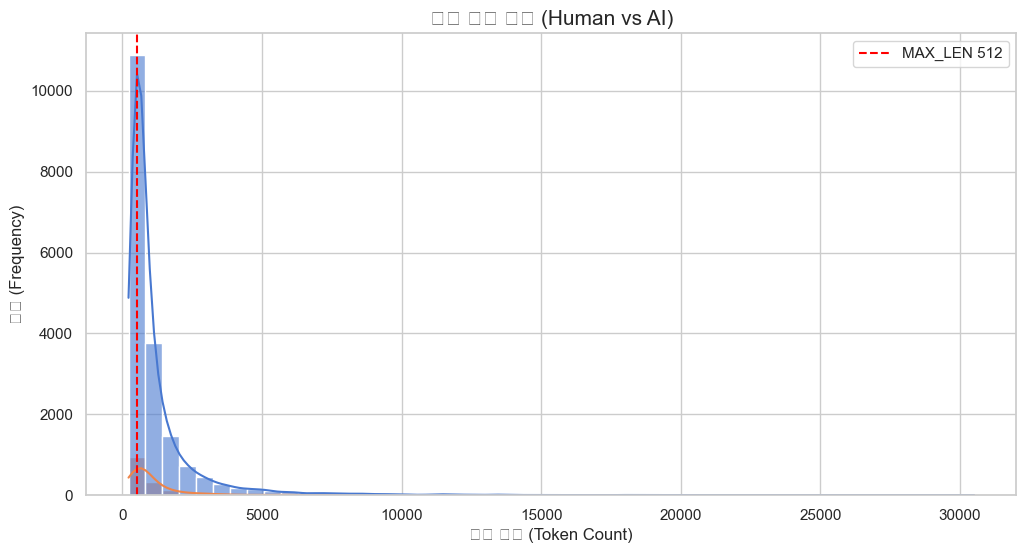

In [5]:
plt.figure(figsize=(12, 6))

# 히스토그램
sns.histplot(data=sample_df, x='token_length', hue='generated', kde=True, bins=50, alpha=0.6)
plt.axvline(x=512, color='red', linestyle='--', label='MAX_LEN 512')
plt.title('토큰 길이 분포 (Human vs AI)', fontsize=15)
plt.xlabel('토큰 개수 (Token Count)')
plt.ylabel('빈도 (Frequency)')
plt.legend()
plt.show()

## ✂️ Truncation (데이터 손실) 분석
`MAX_LEN`을 다르게 설정했을 때, 몇 %의 데이터가 손실(잘림)되는지 확인합니다.

In [6]:
max_lens = [128, 256, 384, 512, 1024]
truncation_data = []

for ml in max_lens:
    truncated_count = (sample_df['token_length'] > ml).sum()
    percentage = truncated_count / len(sample_df) * 100
    truncation_data.append({
        'MAX_LEN': ml,
        'Truncated_Count': truncated_count,
        'Truncation_Rate (%)': round(percentage, 2)
    })

trunc_df = pd.DataFrame(truncation_data)
print("--- ✂️ MAX_LEN별 데이터 손실률 ---")
display(trunc_df)

--- ✂️ MAX_LEN별 데이터 손실률 ---


,MAX_LEN,Truncated_Count,Truncation_Rate (%)
0,128,20000,100.00
1,256,19999,100.00
2,384,18909,94.54
3,512,14250,71.25
4,1024,6263,31.32


## 💡 결론 및 인사이트

1. **데이터 분포**: (통계 수치를 보고 작성)
2. **AI vs Human 차이**: (그래프를 보고 작성)
3. **권장 MAX_LEN**: 
   - 만약 95% 이상의 데이터가 256 내에 들어온다면, 학습 속도를 위해 `MAX_LEN=256`이 효율적입니다.
   - 만약 512를 넘는 데이터가 많다면, `MAX_LEN=512`를 유지하거나 중요 정보를 앞부분으로 모으는 전략이 필요합니다.